# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
from plotnine import *

import requests
import json
import re
import sys
from bs4 import BeautifulSoup
from tqdm import tqdm
pd.set_option("display.max_columns", None)

import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
import ast  # Helps convert string representations of lists

import gspread
from oauth2client.service_account import ServiceAccountCredentials
from gspread_dataframe import set_with_dataframe

In [2]:
#!pip install gspread gspread_dataframe oauth2client

# Global Variables

In [3]:
# Set up credentials and connect to Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("gsheet-creds.json", scope)
client = gspread.authorize(creds)

# Set up credentials and connect to Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("gsheet-creds.json", scope)
client = gspread.authorize(creds)


# Functions

In [4]:
def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a countplot from a column in a pandas DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Your input DataFrame.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Optional query string to filter the DataFrame (e.g., "type == 'Neither'").
    title : str, optional
        Title for the plot.
    color : str, optional
        Bar color (default: '#4C72B0').
    horizontal : bool, default True
        If True, plot bars horizontally.
    figsize : tuple, optional
        Figure size in inches.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            pos_x = p.get_width() + 0.5 if horizontal else p.get_x() + p.get_width() / 2
            pos_y = p.get_y() + p.get_height() / 2 if horizontal else p.get_height() + 0.5
            if horizontal:
                ax.text(count + 0.5, p.get_y() + p.get_height()/2, str(count), va='center')
            else:
                ax.text(p.get_x() + p.get_width()/2, count + 0.5, str(count), ha='center')

    ax.set_title(title or f"Count of {col}")
    ax.set_xlabel("Count" if horizontal else col)
    ax.set_ylabel(col if horizontal else "Count")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

def View(df, rows=None, cols=None, width=None):
    """Displays the first `rows` of the DataFrame like R's View() by adjusting Pandas settings."""
    
    # Show only the first `rows` of the DataFrame
    with pd.option_context(
        "display.max_rows", rows,  # Limit number of rows shown
        "display.max_columns", cols,  # Show all columns
        "display.max_colwidth", width,  # Show full column width
        "display.expand_frame_repr", False  # Prevent column wrapping
    ):
        display(df.head(rows))  # Show only the first `rows`

# Function to extract mod directory from the URL
def get_dir(url):
    match = re.search(r"file=([^/]+)/[^/]+\.mod", url)  # Extract the directory name before the .mod file
    return match.group(1) if match else None  # Return directory name if found, else None

# Function to extract mod file name without extension
def get_fname(url):
    match = re.search(r"/([^/]+)\.mod$", url)  # Get filename without extension
    return match.group(1) if match else None  # Return only the name (e.g., 'na')

# Function to extract model_id from the URL
def get_model_id(url):
    match = re.search(r"https://modeldb\.science/(\d+)", url)
    return int(match.group(1)) if match else None  # Convert to integer

# Function to extract all TITLE occurrences from .mod content
def get_title(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"^TITLE\s+([^\n:]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None

# Function to extract all COMMENT sections from .mod content
def get_comment(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"COMMENT\s+(.*?)(?:\s+ENDCOMMENT|\Z)", content, re.DOTALL)  
    return matches if matches else None

# Function to extract all SUFFIX occurrences from .mod content
def get_suffix(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"SUFFIX\s+([^\n:\s]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None


def get_use_ion(content):
    """
    Extracts the ion names used in the 'USEION' statements from NEURON mod file content.

    Parameters:
    - content (str): The content of the .mod file.

    Returns:
    - list: A list of ions used in 'USEION' statements, or None if none are found.
    """
    if pd.isna(content):  
        return None
    
    # Find all occurrences of USEION followed by an ion name
    matches = re.findall(r"USEION\s+(\w+)", content, re.MULTILINE)

    return matches if matches else None


# Function to extract all ions listed after READ but stopping before WRITE, USEION, RANGE, GLOBAL, NONSPECIFIC_CURRENT, or VALENCE
def get_read_ion(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"USEION\s+\w+\s+READ\s+([\w,\s]+?)(?=\s+(?:WRITE|USEION|RANGE|GLOBAL|NONSPECIFIC_CURRENT|VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    read_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return read_ions if read_ions else None  


# Function to extract all ions listed after WRITE, stopping before VALENCE
def get_write_ion(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"WRITE\s+([^\n:]+?)(?=\s+(?:VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    write_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return write_ions if write_ions else None  


def write_current_yn(ions):
    """
    Checks if mod_write_ion contains an ion that starts with 'i' (indicating a current).

    Args:
        write_ions (list): List of ions written in the mod file.

    Returns:
        int: 1 if any ion starts with 'i', otherwise 0.
    """
    if not ions:  # Handle empty lists or None
        return 0

    return int(any(ion.startswith("i") for ion in ions))


# Function to extract all NONSPECIFIC currents
def get_nonspecific_current(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"NONSPECIFIC_CURRENT\s+([^\n:]*)", content)

    if not matches:
        return None

    nonspecific_currents = [curr.strip() for match in matches for curr in re.split(r"[,\s]+", match) if curr]

    return nonspecific_currents if nonspecific_currents else None  

#todo: should we assume we only want active variables or also extract ones that are commented out?
# Function to extract RANGE variables based on mode
def get_range(content, mode="active"):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract active RANGE variables (not commented out)
    active_matches = re.findall(r"^\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Extract commented-out RANGE variables (lines starting with ": RANGE")
    commented_matches = re.findall(r"^\s*:\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Process active RANGE variables
    active_vars = [var.strip() for match in active_matches for var in re.split(r"[,\s]+", match) if var]

    # Process commented-out RANGE variables
    commented_vars = [var.strip() for match in commented_matches for var in re.split(r"[,\s]+", match) if var]

    if mode == "active":
        return active_vars if active_vars else None
    elif mode == "commented":
        return commented_vars if commented_vars else None
    elif mode == "all":
        return {"active": active_vars if active_vars else None, "commented": commented_vars if commented_vars else None}
    else:
        raise ValueError("Invalid mode! Choose from 'all', 'active', or 'commented'.")


# Function to extract only active RANGE variables, stopping at colons and the end of the line
def get_range(content):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract all RANGE statements (each line separately), stopping before colons
    matches = re.findall(r"^\s*RANGE\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    # Process active RANGE variables, ensuring they don't capture anything past the colon
    active_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return active_vars if active_vars else None  # Return only active variables
    
# Function to extract parameter names and values as a dictionary
def get_parameter(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"PARAMETER\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    param_dict = {}
    
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore commented-out lines
                continue
            param_match = re.match(r"(\w+)\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
            if param_match:
                param_name, param_value = param_match.groups()
                param_dict[param_name] = float(param_value)  

    return param_dict if param_dict else None  

# Function to extract only active STATE variables, ignoring comments (`:`) and unit values `(mV)`, etc.
def get_state(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"STATE\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    state_vars = []
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore fully commented-out lines
                continue
            line = re.split(r"\s*:\s*", line)[0]  # Remove inline comments (anything after `:`)
            clean_line = re.sub(r"\([^)]*\)", "", line).strip()  # Remove unit values
            if clean_line:
                state_vars.append(clean_line)

    return state_vars if state_vars else None  


# Function to extract only active GLOBAL variables, ignoring commented-out (`:`) ones
def get_global(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"^\s*GLOBAL\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    global_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return global_vars if global_vars else None  


def get_net_receive(content):
    """
    Extracts all NET_RECEIVE block arguments from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted NET_RECEIVE arguments, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of NET_RECEIVE and extract arguments
    matches = re.findall(r"^\s*NET_RECEIVE\s*\(\s*([\w, ]+)\s*\)", content, re.MULTILINE)

    if not matches:
        return None

    net_receive_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return net_receive_vars if net_receive_vars else None

#todo: modify pipeline so that if get_include points to a file that file will be included in the content too
def get_include(content):
    """
    Extracts the filename in the INCLUDE statement from MOD file content, ignoring comments.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted INCLUDE filenames, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of INCLUDE, ensuring commented-out ones (with ':') are ignored
    matches = re.findall(r"^\s*INCLUDE\s+\"([^\"]+)\"", content, re.MULTILINE)

    return matches if matches else None


def get_point_process(content):
    """
    Extracts the POINT_PROCESS name from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        str or None: The extracted POINT_PROCESS name, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Extract the POINT_PROCESS name, ignoring comments
    match = re.search(r"^\s*POINT_PROCESS\s+([^\n:]+)", content, re.MULTILINE)

    return match.group(1).strip() if match else None


    
# Function to extract webpage heading
def get_heading(url):
    try:
        response = requests.get(url, timeout=10)  # Fetch the webpage
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Try extracting heading from the most relevant tag
        heading = soup.find("h1")  # Look for <h1> (main title)
        return heading.text.strip() if heading else None  # Return text or None
    except requests.exceptions.RequestException:
        return None  # Return None if the request fail

# Function to extract citation (text inside parentheses)
def get_citation(heading):
    if pd.isna(heading):
        return None
    match = re.search(r"\(([^)]+)\)", heading)  # Find text inside parentheses
    return match.group(1) if match else None  # Extract citation


# Function to extract first author(s) (removes "et al." and "al" correctly)
def get_author(citation):
    if pd.isna(citation):
        return None

    # Extract first author(s) before "et al" or variants
    match = re.search(r"^([\w\s&\-,]+?)(?:\s+et\s+al\.?|et)?(?:,|\s|$)", citation)  
    first_author = match.group(1).strip() if match else None  

    # Remove any trailing "al" left behind
    if first_author:
        first_author = re.sub(r"\b(al)\b", "", first_author, flags=re.IGNORECASE).strip()

    return first_author

# Function to extract the first year from citation (including shortened years like '20)
def get_year(citation):
    if pd.isna(citation):
        return None
    match = re.search(r"\b(19|20)?\d{2}\b|'\d{2}", citation)  # Find 4-digit or short year ('20)
    if match:
        return match.group(0).replace("'", "")  # Remove apostrophe but keep year as '20' if short
    return None  # Return None if no year found






def has_electrode_or_clamp(mod_name, content):
    """
    Checks whether 'clamp' is present in the mod file name OR 
    'ELECTRODE_CURRENT' is present in the NEURON mod file content.

    Parameters:
    - mod_name (str): The name of the .mod file.
    - content (str): The content of the .mod file.

    Returns:
    - int: 1 if either 'clamp' is in the mod name OR 'ELECTRODE_CURRENT' is in the content, 0 otherwise.
    """
    if pd.isna(mod_name) and pd.isna(content):
        return None  # Return None if both are missing

    has_clamp = bool(re.search(r"clamp", str(mod_name), re.IGNORECASE)) if pd.notna(mod_name) else False
    has_electrode = bool(re.search(r"\bELECTRODE_CURRENT\b", str(content))) if pd.notna(content) else False

    return 1 if has_clamp or has_electrode else 0

def map_ion(value):
    value = value.lower()  # Normalize to lowercase

    # Define regex-based categorization rules
    patterns = [
        (r'ca.*i$', 'ca_i'),
        (r'ca.*o$', 'ca_o'),
        (r'cl.*i$', 'cl_i'),
        (r'cl.*o$', 'cl_o'),
        (r'k.*i$', 'k_i'),
        (r'k.*o$', 'k_o'),
        (r'na.*i$', 'na_i'),
        (r'na.*o$', 'na_o'),
        (r'hco3.*i$', 'other_i'),
        (r'hco3.*o$', 'other_o'),
        (r'mgi$', 'mg_i'),  
        (r'mgo$', 'mg_o'),  
        (r'^img$', 'i_mg'),  
        (r'^emg$', 'e_mg'),
        (r'^e.*ca', 'e_ca'),
        (r'^e.*k', 'e_k'),
        (r'^e.*na', 'e_na'),
        (r'^e.*mg', 'e_mg'),
        (r'^e.*', 'e_other'),
        (r'^i.*ca', 'i_cal'),
        (r'^i.*k', 'i_k'),
        (r'^i.*cl', 'i_cl'),
        (r'^i.*na$', 'i_na'),  # FIX: Ensure "ina" is classified as "i_na"
        (r'^i.*mg', 'i_mg'),
        (r'^i.*', 'i_other'),
        (r'.*i$', 'other_i'),  # General rule: Anything ending in "i" is "other_i"
        (r'.*o$', 'other_o')   # General rule: Anything ending in "o" is "other_o"
    ]
    # Apply the regex patterns
    for pattern, category in patterns:
        if re.search(pattern, value):
            return category

    return "unknown"  # Default category if no match is found

def count_states(df, column_name="state"):
    """Counts the number of states in each row of the specified column."""
    df["count_states"] = df[column_name].apply(lambda x: len(x) if isinstance(x, list) else 0)
    return df



def get_tau(param_dict):
    if not isinstance(param_dict, dict):
        return None, None  # Return separate None values for direct unpacking

    # Extract values where the key contains 'tau'
    tau_values = [v for k, v in param_dict.items() if 'tau' in k.lower()]
    
    # If no tau values found, return (None, None)
    if not tau_values:
        return None, None
    
    # Compute min and max
    return min(tau_values), max(tau_values)


def get_e(param_dict):
    if not isinstance(param_dict, dict):
        return [None, None]  # Handle cases where the value is not a dictionary

    #todo: modify the v pattern so it takes like 2 characters max
    # Regex pattern to match variations of reversal potential names
    pattern = re.compile(r"^(e|rev|v|shift).*", re.IGNORECASE)

    # Extract values where the key matches the pattern
    e_values = [v for k, v in param_dict.items() if pattern.match(k)]

    # If no values found, return [None, None]
    if not e_values:
        return [None, None]

    # Compute min and max reversal potential
    return min(e_values), max(e_values)



def has_mg(content):
    """
    Checks if 'mg' appears anywhere in the given content.

    Args:
        content (str): The text content to search.

    Returns:
        int: 1 if 'mg' is found, 0 otherwise.
    """
    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"mg", content, re.IGNORECASE)))  # Convert Boolean to int


def has_ih(content):

    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"ih", content, re.IGNORECASE)))  # Convert Boolean to int

def plot_countplot(
    df,
    col,
    subset_query=None,
    title=None,
    color='#4C72B0',
    horizontal=True,
    figsize=(8, 5),
    show_counts=False
):
    """
    Create a Seaborn countplot with options for filtering, orientation, and annotations.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input data.
    col : str
        Column to count and plot.
    subset_query : str, optional
        Pandas query string to filter data before plotting (e.g., "type == 'Neither'").
    title : str, optional
        Title of the plot.
    color : str, optional
        Color of the bars.
    horizontal : bool, default True
        If True, plot horizontal bars; else vertical.
    figsize : tuple, default (8, 5)
        Figure size.
    show_counts : bool, default False
        If True, annotate bars with counts.
    """
    data = df.query(subset_query) if subset_query else df
    order = data[col].value_counts().index

    plt.figure(figsize=figsize)
    ax = sns.countplot(
        data=data,
        y=col if horizontal else None,
        x=None if horizontal else col,
        order=order,
        color=color
    )

    if show_counts:
        for p in ax.patches:
            count = int(p.get_width() if horizontal else p.get_height())
            if horizontal:
                ax.text(
                    p.get_width() + 0.5,
                    p.get_y() + p.get_height() / 2,
                    str(count),
                    va='center'
                )
            else:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    p.get_height() + 0.5,
                    str(count),
                    ha='center'
                )

    ax.set_title(title or f'Count of {col}')
    ax.set_xlabel('Count' if horizontal else col)
    ax.set_ylabel(col if horizontal else 'Count')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

# Highlight count < 10
def highlight_rare_rows(row):
    color = 'background-color: lightcoral' if row['count'] < 10 else ''
    return [color] * len(row)


def get_count_df(df, group_cols, sort_col=None):
    if sort_col is None:
        sort_col = group_cols[0]
    
    return (
        df
        .groupby(group_cols)
        .size()
        .reset_index(name='count')
        .assign(
            overall_pct = lambda d: (d['count'] / d['count'].sum() * 100).round(2),
            subtype_pct = lambda d: (
                d.groupby(group_cols[0])['count']
                .transform(lambda x: (x / x.sum()) * 100)
                .round(2)
            )
        )
        .sort_values([sort_col, 'count'], ascending=[True, False])
    )

def plot_partial_credit_heatmap(y_true, y_pred, similarity_matrix):
    """
    Plots a heatmap of average similarity scores between true and predicted labels.
    
    Parameters:
    - y_true: list or array of true labels (strings)
    - y_pred: list or array of predicted labels (strings)
    - similarity_matrix: pandas DataFrame with labels as index and columns, containing similarity scores
    """
    # Get all unique labels
    all_labels = sorted(set(y_true) | set(y_pred))
    
    # Build confusion-style count matrix
    confusion_counts = pd.DataFrame(0, index=all_labels, columns=all_labels)
    for true, pred in zip(y_true, y_pred):
        confusion_counts.loc[true, pred] += 1

    # Compute similarity-weighted scores
    weighted_scores = confusion_counts * similarity_matrix

    # Normalize to average similarity per true label
    normalized_similarity = weighted_scores.div(confusion_counts.sum(axis=1).replace(0, np.nan), axis=0)

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(normalized_similarity, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Average Partial Credit Score: True vs Predicted")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

import re
import sys

def extract_membrane_potential_value(line: str):
    # Remove comments starting with colon
    line = line.split(':', 1)[0]
    # Remove all whitespace
    cleaned = re.sub(r'\s+', '', line)

    # Regex pattern
    pattern = r'^([a-zA-Z_][a-zA-Z0-9_]*)=([-+]?\d+(\.\d+)?([eE][-+]?\d+)?)[(]mV[)]$'
    match = re.match(pattern, cleaned)
    
    if match:
        return float(match.group(2))
    return None

def extract_comparison_values(expr: str):
    expr = re.sub(r':.*$', '', expr)  # Strip comments
    expr = re.sub(r'\s+', '', expr)   # Remove all whitespace

    var = 'v' if 'v' in expr else ('Vm' if 'Vm' in expr else None)
    if var is None:
        return None, None

    values = []

    # Pattern for `var` ... `[+/-] Number` (e.g., `v+30`, `v+vshift-40`)
    # This also covers cases where the *variable* has a leading sign within a larger expression
    # but the structure is essentially `( [+-]var ... [+-]Number )`.
    # We need to be careful with `sign_before_var` for this one.

    # Pattern for terms like `v+C` or `v-C` directly, or `Av+C` where A is 1 or -1 after preprocessing.
    # This should be the most direct way to get `C` for `v+/-C` or `(+-v)+C`.
    # Let's adjust this to specifically match `([+-]?var)` followed by `[+-]num`
    # and also `num[+-]([+-]?var)`.

    # Attempt to capture the coefficient of 'v' and the constant term, then solve.
    # This is still simplified for linear patterns.
    pattern_linear_term_extraction = re.compile(rf"""
        (?:
            # Case: Number +/- var (e.g., 57 - v, 30 + v)
            (?P<num_before>[-+]?\d+(?:\.\d+)?) \s* (?P<op_num_var>[+-]) \s* ({re.escape(var)})
            |
            # Case: var +/- Number (e.g., v + 30, -v + 19.88, vshift + v - 57)
            # This needs to handle a leading sign for the var.
            (?P<sign_var>[+-]?) ({re.escape(var)}) # Capture optional sign before var
            (?: \s* [+-] \s* [a-zA-Z_]\w* )* # Other vars/ops between var and number
            \s* (?P<op_var_num>[+-]) \s* (?P<num_after>[-+]?\d+(?:\.\d+)?)
        )
    """, re.VERBOSE)

    # Special handling for `-(v+shift+vsym+50)/7.4`
    pattern_nested_negation = re.compile(rf"""
        -\s*\( # Starts with - followed by (
        .*? # Non-greedy match for anything
        {re.escape(var)} # Contains the target variable
        (?: \s* [+-] \s* [a-zA-Z_]\w* )* # Optional other variables
        \s*
        (?P<op_final_nested>[+-]) # The operator before the constant
        \s*
        (?P<num_final_nested>\d+(?:\.\d+)?) # The positive constant
        \s*\) # Closing parenthesis
    """, re.VERBOSE)

    # --- Apply Patterns and Extract Values ---

    # For the linear term extraction pattern
    for match in pattern_linear_term_extraction.finditer(expr):
        if match.group('num_before'): # Matched: Number +/- var
            number = float(match.group('num_before'))
            op = match.group('op_num_var')
            # If `N - v`, means `N` is constant. `v=N`.
            # If `N + v`, means `N` is constant. `v=-N`.
            cmp_val = number if op == '-' else -number
            values.append(cmp_val)
        else: # Matched: [+-]var +/- Number
            number = float(match.group('num_after'))
            op = match.group('op_var_num')
            sign_var = match.group('sign_var') # Will be '-', '+' or ''

            # Effective coefficient of v (after preprocessing 1s)
            effective_var_coeff = -1.0 if sign_var == '-' else 1.0

            # Effective constant term (B) for Av+B
            # If op is '+', B is +number. If op is '-', B is -number.
            effective_constant = number if op == '+' else -number # Corrected logic

            # Solve Av + B = 0 => v = -B/A
            if effective_var_coeff != 0: # Should always be 1 or -1 here
                cmp_val = -effective_constant / effective_var_coeff
                values.append(cmp_val)


    for match in pattern_nested_negation.finditer(expr):
        number = float(match.group('num_final_nested'))
        op = match.group('op_final_nested')
        # This handles `-(v+50)` and `-(v-50)`
        # If op is '+', it's `-(v+N)`, which is `-v-N`. So `-v-N=0` => `v=-N`.
        # If op is '-', it's `-(v-N)`, which is `-v+N`. So `-v+N=0` => `v=N`.
        cmp_val = -number if op == '+' else number
        values.append(cmp_val)

    return list(set(values)) # Use set to remove duplicates


# Regex to find -1 times v or Vm (with optional decimals and spaces)
pattern_neg_one_mul = re.compile(r"-\s*1\.?0*\*\s*([vV]m?)")


def extract_v_comparisons(expr_str: str):
    # Replace with just - followed by the captured variable
    old_expr = expr_str
    expr_str = pattern_neg_one_mul.sub(r"-\g<1>", expr_str)
    if old_expr != expr_str:
        print(old_expr)
        print(expr_str)
    extracted_values = extract_comparison_values(expr_str)
    if None in extracted_values or not extracted_values:
        return None, None
    else:
        # Return min and max if values were found
        return min(extracted_values), max(extracted_values)


def extract_voltage_extrema(mod_content: str):
    values = []

    for line in mod_content.splitlines():
        # Strip comments
        code = line.split(':', 1)[0]

        # Skip empty lines
        if not code.strip():
            continue

        # Try membrane potential definition
        mv_val = extract_membrane_potential_value(code)
        if mv_val is not None:
            values.append(mv_val)

        # Try v comparison
        vmin, vmax = extract_v_comparisons(code)
        if vmin is not None:
            values.extend([vmin, vmax])

    if values:
        return min(values), max(values)
    return None, None


# Key Variables

In [5]:
#These are subtypes with counts < 10
RARE_SUBTYPES = ['I Na (Rare)',
 'I Ca (Rare)',
 'I K (Leak)',
 'I Other (Rare)',
 'I Na (Leak)',
 'R Other (Rare)',
 'I Cl ']


COMMON_SUBTYPES_ROBERT = ['I R',
 'I Ca,p',
 'I p,q',
 'I L high threshold',
 'I T low threshold',
 'I h',
 'I A',
 'I A',
 'I_AHP',
 'IK Bkca',
 'IK Skca',
 'I K,Ca',
 'I_KD',
 'I M',
 'I KLT',
 'I K',
 'I Potassium',
 'I_KHT',
 'Kir',
 'I K, I K,s',
 'I Ks',
 'I Sodium',
 'I Na,p',
 'I Na,t',
 'I CAN',
 'I N',
 'Ca pump',
 'Na/K pump',
 'Na/Ca exchanger',
 'GabaA',
 'Gaba',
 'GabaB',
 'AMPA',
 'NMDA']

# Import Data

## Google Sheet (Labels)

In [6]:
# Open the sheet by name
sheet = client.open("label_df").sheet1

# Read sheet data into DataFrame
data = sheet.get_all_records()
label_df = pd.DataFrame(data).query("new_subtype_label not in @RARE_SUBTYPES")

label_df_long = (
    label_df
    .assign(
        robert_subtype_label=label_df['robert_subtype_label']
        .str.split(' \|\| ')
    )
    .explode('robert_subtype_label')
    .assign(
        robert_subtype_label=lambda df: df['robert_subtype_label']
        .str.strip()
        .replace("", pd.NA)
    )
)

In [7]:
label_df.head()

,original_type_label,original_subtype_label,robert_subtype_label,new_subtype_label
0,Exclude,Exclude - Not on Model DB,,Exclude
1,Exclude,Exclude - Old Architecture,,Exclude
2,Exclude,Exclude - Accumulation Mechanism,,Exclude
3,I Ca,I Ca (R-Type),I R,I Ca (HVA)
4,I Ca,I Ca (P/Q-Type),"I Ca,p || I p,q",I Ca (HVA)


## Annotated Excel Sheet

In [8]:
fp = "/gpfs/gibbs/project/mcdougal/imc33/mod-extract/data/raw/model_db_annotations.xlsx"
raw_ant_df_wide = pd.read_excel(fp).query("annotated == 'y'")

missing_subtype1_df = raw_ant_df_wide[raw_ant_df_wide["subtype_1"].isna()]

raw_ant_df_long = (raw_ant_df_wide
    .melt(
        id_vars=[col for col in raw_ant_df_wide.columns if col not in ['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5']],
        value_vars=['subtype_1', 'subtype_2', 'subtype_3', 'subtype_4', 'subtype_5'],
        var_name="subtype_num",
        value_name="original_subtype_label"
    ))

ant_df_long = (raw_ant_df_long
    .dropna(subset=["original_subtype_label"])
    #Exclusion Criteria here 
    .query("subtype_confidence != '1 - Not confident at all'")
    .query("type != 'Exclude'")
    .drop(columns=['raw_sha','count','url','mod_file','ask_robert','annotated','Robert reviewed','subtype_num'])
    .merge(label_df, on="original_subtype_label", how="left")
    .sort_values('row_id')
    .query("type != 'I Multi'")
    .query("type != 'R Multi'")
    .query("new_subtype_label not in @RARE_SUBTYPES")
   # .assign(
   #     type = lambda df: np.where(
   #         df["type"] == "I Multi",
   #         df["original_type_label"],
   #         df["type"]
   #     )
    ).drop(columns=["robert_subtype_label"])


def get_metrics_df(conf_input, labels=None):
    """
    Compute True Positives, Count, and TP % from a confusion matrix.

    Parameters:
        conf_input (DataFrame or ndarray): Confusion matrix
        labels (list or array-like, optional): Class labels (required if conf_input is ndarray)

    Returns:
        DataFrame with metrics per class
    """
    # Convert to DataFrame if needed
    if isinstance(conf_input, np.ndarray):
        if labels is None:
            raise ValueError("Must provide 'labels' if confusion matrix is a NumPy array.")
        conf_df = pd.DataFrame(conf_input, index=labels, columns=labels)
    else:
        conf_df = conf_input.copy()
        if labels is None:
            labels = conf_df.index.tolist()

    # Create metrics
    metrics_df = pd.DataFrame(index=labels)
    metrics_df["True Positives"] = np.diag(conf_df.values)
    metrics_df["Count"] = conf_df.sum(axis=1).values
    metrics_df["TP %"] = 100 * metrics_df["True Positives"] / metrics_df["Count"]
    metrics_df = metrics_df.round(2)

    return metrics_df


/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


In [9]:
ant_df_long["type"].value_counts()

type
I K         235
Neither     183
I Na         94
Receptor     85
I Ca         75
I Other      50
I H          38
I Cl          1
Name: count, dtype: int64

In [10]:
# Only fill where new_subtype_label is null and type is "IH"
ant_df_long.loc[
    ant_df_long["new_subtype_label"].isna() & (ant_df_long["type"] == "I H"),
    "new_subtype_label"
] = "I H (Hyperpolarization-Activated)"


## GPT-4
- These are the subtypes present in our 1k annotation set that are missing from GPT
- Not shown, the GPT dataset included the following: "D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'" which are missing form our 1k dataset

In [11]:
raw_gpt_df = pd.read_csv("../data/raw/mod_files_gpt.csv", usecols=["hash","currents_at_least_3"]).rename(columns={"currents_at_least_3":"gpt_pred"})
raw_gpt_df.head()

,hash,gpt_pred
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,"[""IK Skca""]"
1,04c32cd101754ad7f2eaf278919c6ce85b8a7d67149fca...,"[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]"
2,2d3c5c121271cfad6d2e35db7d2c418de64f97e57c20a0...,"[""I T low threshold""]"
3,e2f71ea16f8378b3cf0670f9bd5e457634824ab9ee8a7c...,"[""I K""]"
4,04860f65d331d381e779e488566f95ab0e1fa4960b50a7...,[]


In [12]:
#'D1', 'D2', 'Dopaminergic Receptor', 'M1', 'M2', 'M3', 'M4'
#label_df_long[label_df_long.robert_subtype_label.isna()]

In [13]:
import ast
import pandas as pd

gpt_df2 = (
    raw_gpt_df
    .assign(gpt_pred=lambda df: df['gpt_pred'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x))
    .explode('gpt_pred')
    .assign(gpt_pred=lambda df: df['gpt_pred'].str.strip().replace("", pd.NA))
)

In [14]:
gpt_df3 = (gpt_df2
         .query("gpt_pred in @COMMON_SUBTYPES_ROBERT")
         .query("gpt_pred not in @RARE_SUBTYPES")
         .merge(label_df_long, how="left", left_on=["gpt_pred"], right_on=["robert_subtype_label"])
        .drop(columns=["gpt_pred","robert_subtype_label","original_subtype_label"])
        .rename(columns={"new_subtype_label":"gpt_pred_subtype","original_type_label":"gpt_pred_type"})
          )

# Check Rare Labels
- If count < 10, then collapse into another category; if no category fits, then collapse into Rare
- This is the google sheet: https://docs.google.com/spreadsheets/d/1gZ9pdoGwL_jVwC8APBZ_zb0jzLwl2hg3hIdfmLLEmRY/edit?gid=235253285#gid=235253285

In [15]:
#count_df  = get_count_df(ant_df_long, ['type', 'original_subtype_label'])
#count_df2 = get_count_df(ant_df_long, ['type', 'new_subtype_label'])
#count_df.sort_values(['type','original_subtype_label'], ascending=[True, False]).reset_index().style.apply(highlight_rare_rows, axis=1)

In [16]:
#count_df2.style.apply(highlight_rare_rows, axis=1)
#todo: should we remove those < 10?
#rare_types = count_df2.query('count<10').sort_values('overall_pct', ascending=False)

# Create Plots

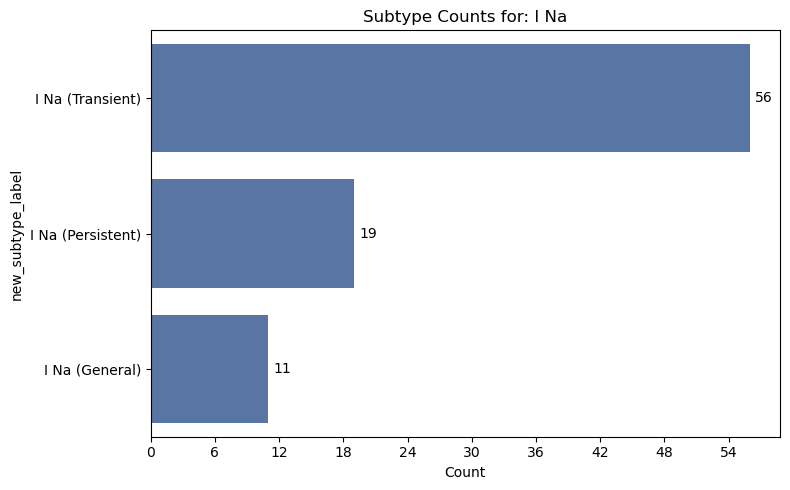

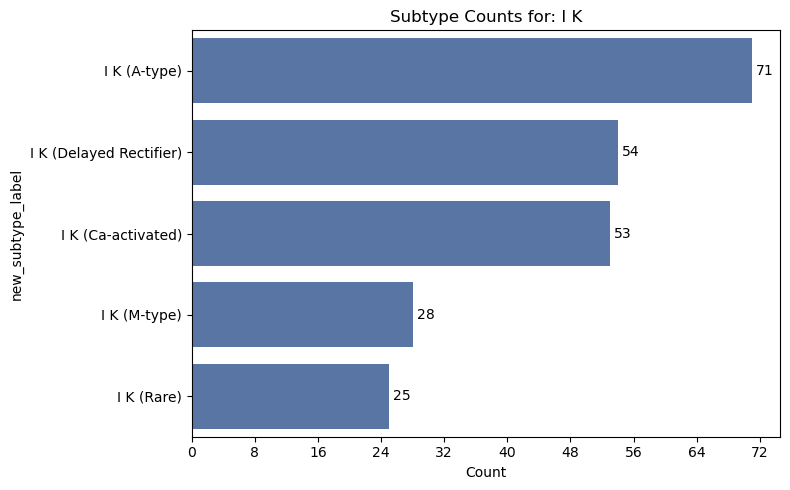

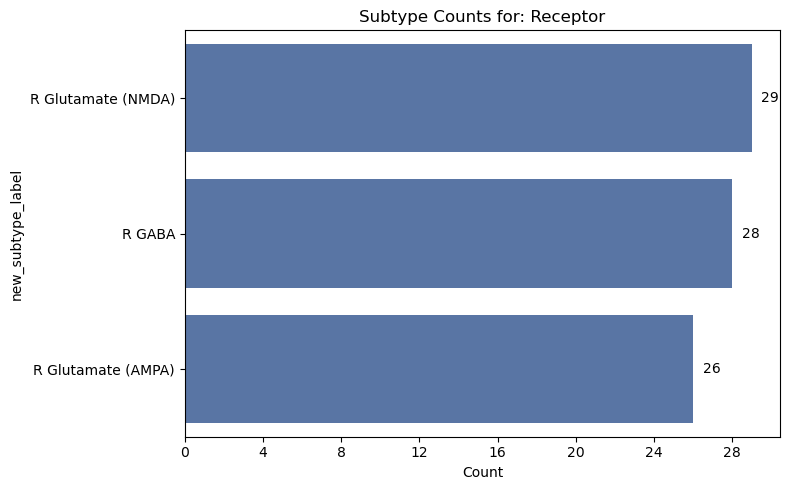

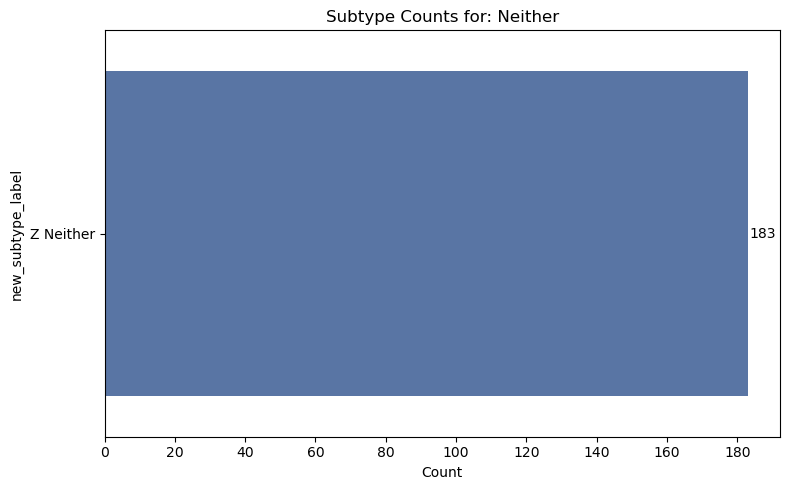

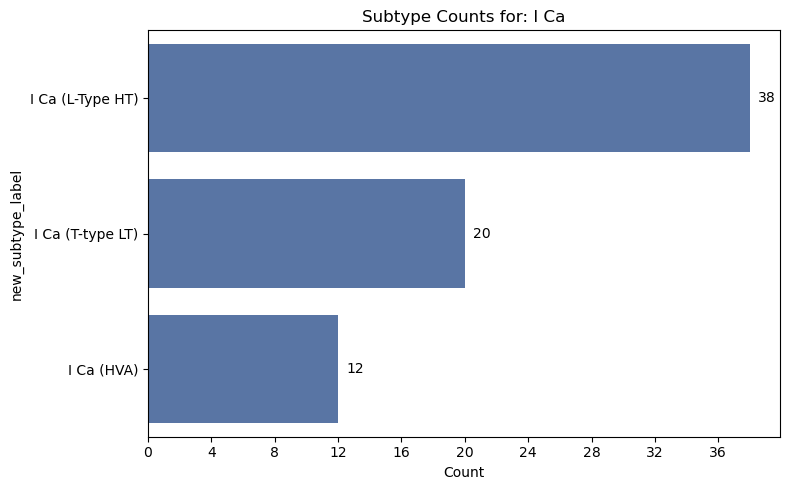

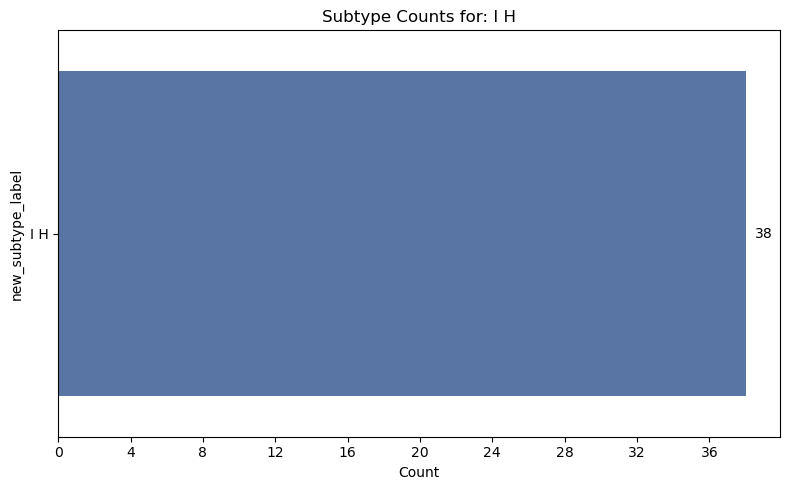

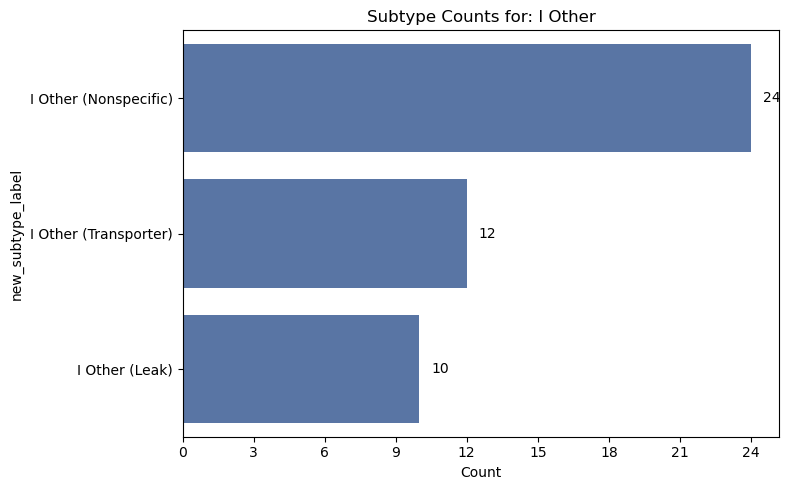

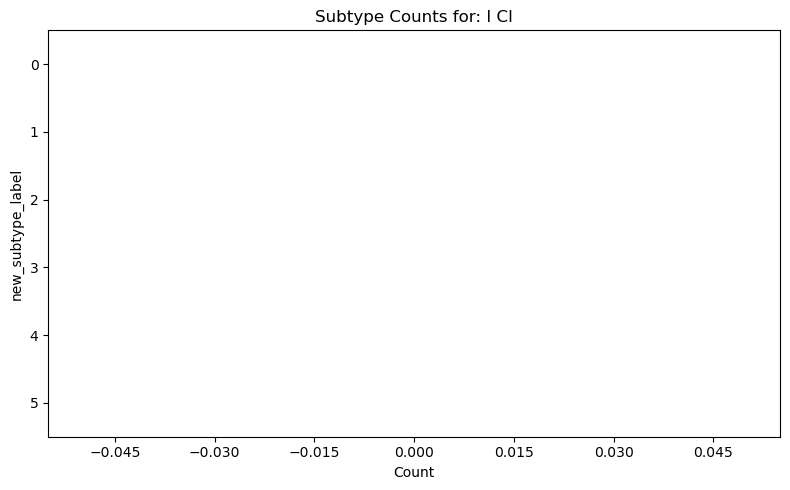

In [17]:
# Loop through each unique type and plot
for t in ant_df_long["type"].dropna().unique():
    plot_countplot(
        df=ant_df_long,
        col='new_subtype_label',
        subset_query=f"type == '{t}'",
        title=f"Subtype Counts for: {t}",
        show_counts=True
    )


# Get Similarity Matrix

In [18]:
labels = [label for label in label_df["new_subtype_label"].unique() if not str(label).startswith("Exclude")]

# Extract label "prefixes" for grouping
def get_prefix(label):
    for separator in [" (", " - "]:
        if separator in label:
            return label.split(separator)[0].strip()
    return label

prefixes = {label: get_prefix(label) for label in labels}

# Initialize similarity matrix
similarity_matrix = pd.DataFrame(0.0, index=labels, columns=labels)

# Fill in similarity scores
for i in labels:
    for j in labels:
        if i == j:
            similarity_matrix.loc[i, j] = 1.0
        elif prefixes[i] == prefixes[j]:
            similarity_matrix.loc[i, j] = 0.5
        elif prefixes[i].split()[0] == prefixes[j].split()[0]:  # e.g., I vs R vs Neither
            similarity_matrix.loc[i, j] = 0.3
        else:
            similarity_matrix.loc[i, j] = 0.0


# Feature Engineering

In [19]:
#ant_df_long[ant_df_long["new_subtype_label"].isna()].sort_values('row_id')

In [20]:
ant_df_long[ant_df_long["row_id"].duplicated()].sort_values('row_id')

,row_id,file_hash,type,subtype_confidence,notes_free_text,original_subtype_label,original_type_label,new_subtype_label


In [21]:
json_df = pd.read_json("../data/raw/mod_files.json")

In [22]:
json_df2 = (
    json_df
    .merge(ant_df_long, on=["row_id", "file_hash"], how="inner")
    .assign(
        mod_name = lambda df: df["url"].apply(get_fname),
        suffix = lambda df: df["content"].apply(get_suffix),
        read_ion = lambda df: df["content"].apply(get_read_ion),
        read_ion2 = lambda df: df["read_ion"].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []),
        write_ion = lambda df: df["content"].apply(get_write_ion),
        write_ion2 = lambda df: df["write_ion"].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []),
        parameter = lambda df: df["content"].apply(get_parameter),
        state = lambda df: df["content"].apply(get_state),
        net_receive = lambda df: df["content"].apply(get_net_receive),
        point_process = lambda df: df["content"].apply(get_point_process),
        nonspecific_current = lambda df: df["content"].apply(get_nonspecific_current),

        # Discrete features
        states_count = lambda df: df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0),

        # Binary features
        clamp_yn = lambda df: df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1),
        suffix_yn = lambda df: df["suffix"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 
                                                  else (0 if pd.isna(x) or x == "none" else 1)),
        point_process_yn = lambda df: df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0),
        net_receive_yn = lambda df: df["net_receive"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)),
        i_nonspecific_yn = lambda df: df["nonspecific_current"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)),
        not_ion_channel_yn = lambda df: ((df["suffix_yn"] == 0) & 
                                         df["read_ion"].isna() & 
                                         df["write_ion"].isna() & 
                                         df["nonspecific_current"].isna()).astype(int),
        not_receptor_yn = lambda df: ((df["point_process_yn"] == 0) & 
                                      (df["net_receive_yn"] == 0)).astype(int),
        has_mg_yn = lambda df: df["content"].apply(has_mg),
        has_ih_yn = lambda df: df["content"].apply(has_ih),
        volt_min = lambda df: df["content"].apply(lambda x: extract_voltage_extrema(x)[0]),
        volt_max = lambda df: df["content"].apply(lambda x: extract_voltage_extrema(x)[1])        
    ).reset_index(drop=True)
)      

	a = 0.2*(-1.0*v+19.26)/(exp((-1.0*v+19.26)/10.0)-1.0)
	a = 0.2*(-v+19.26)/(exp((-v+19.26)/10.0)-1.0)
	alp = 15.69*(-1.0*v+81.5)/(exp((-1.0*v+81.5)/10.0)-1.0)
	alp = 15.69*(-v+81.5)/(exp((-v+81.5)/10.0)-1.0)
	alpm = 0.1967*(-1.0*v+19.88)/(exp((-1.0*v+19.88)/10.0)-1.0)
	alpm = 0.1967*(-v+19.88)/(exp((-v+19.88)/10.0)-1.0)
	alpm = 0.1967*(-1.0*v+19.88)/(exp((-1.0*v+19.88)/10.0)-1.0)
	alpm = 0.1967*(-v+19.88)/(exp((-v+19.88)/10.0)-1.0)
	a = 0.2*(-1.0*v+19.26)/(exp((-1.0*v+19.26)/10.0)-1.0)
	a = 0.2*(-v+19.26)/(exp((-v+19.26)/10.0)-1.0)
	a = 0.2*(-1.0*v+19.26)/(exp((-1.0*v+19.26)/10.0)-1.0)
	a = 0.2*(-v+19.26)/(exp((-v+19.26)/10.0)-1.0)
	alp = scaletau*15.69*(-1.0*v-shiftm+81.5)/(exp((-1.0*v-shiftm+81.5)/10.0)-1.0)
	alp = scaletau*15.69*(-v-shiftm+81.5)/(exp((-v-shiftm+81.5)/10.0)-1.0)
	alp = 15.69*(-1.0*v+81.5)/(exp((-1.0*v+81.5)/10.0)-1.0)
	alp = 15.69*(-v+81.5)/(exp((-v+81.5)/10.0)-1.0)
	alp = 15.69*(-1.0*v+81.5)/(exp((-1.0*v+81.5)/10.0)-1.0)
	alp = 15.69*(-v+81.5)/(exp((-v+81.5)/10.0)-1

In [23]:
# Use MultiLabelBinarizer separately for read and write ions
# Reset index before merging to avoid index mismatches
mlb_read = MultiLabelBinarizer()
read_df = pd.DataFrame(mlb_read.fit_transform(json_df2['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_]).reset_index(drop=True)

mlb_write = MultiLabelBinarizer()
write_df = pd.DataFrame(mlb_write.fit_transform(json_df2['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_]).reset_index(drop=True)

In [24]:
#note: the ones with missing subtype labels are the rare subtypes
#json_df3[json_df3["new_subtype_label"].isna()].shape
json_df3 = json_df2.drop(columns=['read_ion2', 'write_ion2']).join(read_df, rsuffix='_read_dup').join(write_df, rsuffix='_write_dup').dropna(subset=["new_subtype_label"])


In [25]:
print("Total shape", json_df3.shape)
print("Total unique currents/receptors", json_df3["row_id"].nunique())

Total shape (737, 69)
Total unique currents/receptors 737


In [26]:
df_pre = json_df3.set_index('file_hash').filter(regex=r'(_yn|_count|new_subtype_label|volt_min|volt_max)$')

In [27]:
df_pre.to_csv("../data/pipeline/preprocessed.csv")

In [28]:
DATASET = list(df_pre.reset_index()["file_hash"])

In [29]:
#json_df_sample = json_df.query("file_hash in @DATASET")
#json_df_sample.to_json("../data/raw/mod_files_sample.json")

In [30]:
df_pre.head()

,new_subtype_label,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_ih_yn,volt_min,volt_max,read_ca_i_yn,read_ca_o_yn,read_cl_i_yn,read_cl_o_yn,read_e_ca_yn,read_e_k_yn,read_e_na_yn,read_e_other_yn,read_i_cal_yn,read_i_cl_yn,read_i_k_yn,read_i_na_yn,read_i_other_yn,read_k_i_yn,read_k_o_yn,read_na_i_yn,read_na_o_yn,read_other_i_yn,read_other_o_yn,write_ca_i_yn,write_ca_o_yn,write_cl_i_yn,write_cl_o_yn,write_i_cal_yn,write_i_cl_yn,write_i_k_yn,write_i_na_yn,write_i_other_yn,write_k_i_yn,write_k_o_yn,write_na_i_yn,write_na_o_yn,write_other_i_yn,write_unknown_yn
file_hash,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f8be35d0c20d1b1f3de4c44323e1780ee24f06893b6364efc092f38dc8b33959,I Na (Persistent),0,0,1,0,0,0,0,1,0,0,-51.0,45.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
e97ca8a7f9734805832e5ae75442d19d3d7796b9a24190a20d107d1ea27784df,I K (A-type),2,0,1,0,0,0,0,1,0,0,-56.0,11.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
606423f8f4a4f406f3387c7ee6f142bd121237272c347d84024c29b5654ad0d2,R GABA,0,0,0,1,0,1,0,0,0,0,-80.0,-80.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
99713c0032634e96cc7cde2dce02d8aa2baf75ad4cc835330db0d3ba2c1ed1f9,R GABA,1,0,0,1,1,1,0,0,0,0,-75.0,-75.0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10ba049ae44a7641e6f429489d55721ea55e895f9d09fac16ac3b066a314de96,Z Neither,2,0,0,1,0,1,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
json_df3[json_df3.new_subtype_label.isna()]
json_df3[json_df3.type.isna()]

,row_id,file_hash,raw_sha,count,url,download_url,content,error_code,type,subtype_confidence,notes_free_text,original_subtype_label,original_type_label,new_subtype_label,mod_name,suffix,read_ion,write_ion,parameter,state,net_receive,point_process,nonspecific_current,states_count,clamp_yn,suffix_yn,point_process_yn,net_receive_yn,i_nonspecific_yn,not_ion_channel_yn,not_receptor_yn,has_mg_yn,has_ih_yn,volt_min,volt_max,read_ca_i_yn,read_ca_o_yn,read_cl_i_yn,read_cl_o_yn,read_e_ca_yn,read_e_k_yn,read_e_na_yn,read_e_other_yn,read_i_cal_yn,read_i_cl_yn,read_i_k_yn,read_i_na_yn,read_i_other_yn,read_k_i_yn,read_k_o_yn,read_na_i_yn,read_na_o_yn,read_other_i_yn,read_other_o_yn,write_ca_i_yn,write_ca_o_yn,write_cl_i_yn,write_cl_o_yn,write_i_cal_yn,write_i_cl_yn,write_i_k_yn,write_i_na_yn,write_i_other_yn,write_k_i_yn,write_k_o_yn,write_na_i_yn,write_na_o_yn,write_other_i_yn,write_unknown_yn


# XGB model 
- Link to 2025-03-07 results: https://docs.google.com/presentation/d/1glchNMC5hmDNKWJJXEZWrfv2TXf5l8j0cvdH7K_p4xY/edit?slide=id.g2e3c020b9c3_0_256#slide=id.g2e3c020b9c3_0_256

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import pickle

# Load preprocessed data
df_pre = pd.read_csv("../data/pipeline/preprocessed.csv", index_col='file_hash')

# Extract type and subtype
df_pre['type'] = df_pre['new_subtype_label'].str.extract(r'^(I [A-Za-z]+|R [A-Za-z]+|Z Neither)')
df_pre['subtype'] = df_pre['new_subtype_label']

# Split features and labels
X = df_pre.drop(columns=['new_subtype_label', 'type', 'subtype'])
y_type = df_pre['type']
y_subtype = df_pre['subtype']

# Split into train/test sets
X_train, X_test, y_type_train, y_type_test, y_subtype_train, y_subtype_test = train_test_split(
    X, y_type, y_subtype, test_size=0.20, stratify=y_subtype, random_state=42
)

# === Encode type labels ===
type_encoder = LabelEncoder()
y_type_train_enc = type_encoder.fit_transform(y_type_train)
y_type_test_enc = type_encoder.transform(y_type_test)

# === Train XGBoost type model ===
type_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(type_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)
type_model.fit(X_train, y_type_train_enc)

# === Encode subtype labels ===
subtype_encoder = LabelEncoder()
y_subtype_train_enc = subtype_encoder.fit_transform(y_subtype_train)
y_subtype_test_enc = subtype_encoder.transform(y_subtype_test)

# === Train subtype model ===
subtype_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(subtype_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)
subtype_model.fit(X_train, y_subtype_train_enc)

# === Predict hierarchically ===
# Step 1: Predict type
y_type_pred_enc = type_model.predict(X_test)
y_type_pred = type_encoder.inverse_transform(y_type_pred_enc)

# Step 2: Predict subtype
y_subtype_pred_enc = subtype_model.predict(X_test)
y_subtype_pred = subtype_encoder.inverse_transform(y_subtype_pred_enc)

# Step 3: Restrict subtype predictions to same-type examples
filtered_pred = []
filtered_true = []

for true_type, true_sub, pred_type, pred_sub in zip(y_type_test, y_subtype_test, y_type_pred, y_subtype_pred):
    if true_type == pred_type:
        filtered_pred.append(pred_sub)
        filtered_true.append(true_sub)

# === Evaluation ===
print("Type Prediction Accuracy:")
print(accuracy_score(y_type_test, y_type_pred))

print("\nSubtype Accuracy Given Correct Type:")
print(accuracy_score(filtered_true, filtered_pred))

print("\nSubtype Classification Report (only when type was correct):")
print(classification_report(filtered_true, filtered_pred))

# Optional: Save models
output_dir = "../data/pipeline/"

with open(f"{output_dir}type_model.pkl", "wb") as f:
    pickle.dump(type_model, f)

with open(f"{output_dir}subtype_model.pkl", "wb") as f:
    pickle.dump(subtype_model, f)

with open(f"{output_dir}type_encoder.pkl", "wb") as f:
    pickle.dump(type_encoder, f)

with open(f"{output_dir}subtype_encoder.pkl", "wb") as f:
    pickle.dump(subtype_encoder, f)


Type Prediction Accuracy:
0.9054054054054054

Subtype Accuracy Given Correct Type:
0.7611940298507462

Subtype Classification Report (only when type was correct):
                         precision    recall  f1-score   support

             I Ca (HVA)       1.00      0.50      0.67         2
       I Ca (L-Type HT)       0.83      1.00      0.91         5
       I Ca (T-type LT)       1.00      1.00      1.00         4
                    I H       1.00      1.00      1.00         7
           I K (A-type)       0.57      0.57      0.57        14
     I K (Ca-activated)       0.77      1.00      0.87        10
I K (Delayed Rectifier)       0.45      0.50      0.48        10
           I K (M-type)       0.40      0.40      0.40         5
             I K (Rare)       0.33      0.20      0.25         5
         I Na (General)       0.33      0.50      0.40         2
      I Na (Persistent)       1.00      0.25      0.40         4
       I Na (Transient)       0.69      0.82      0.75  

/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


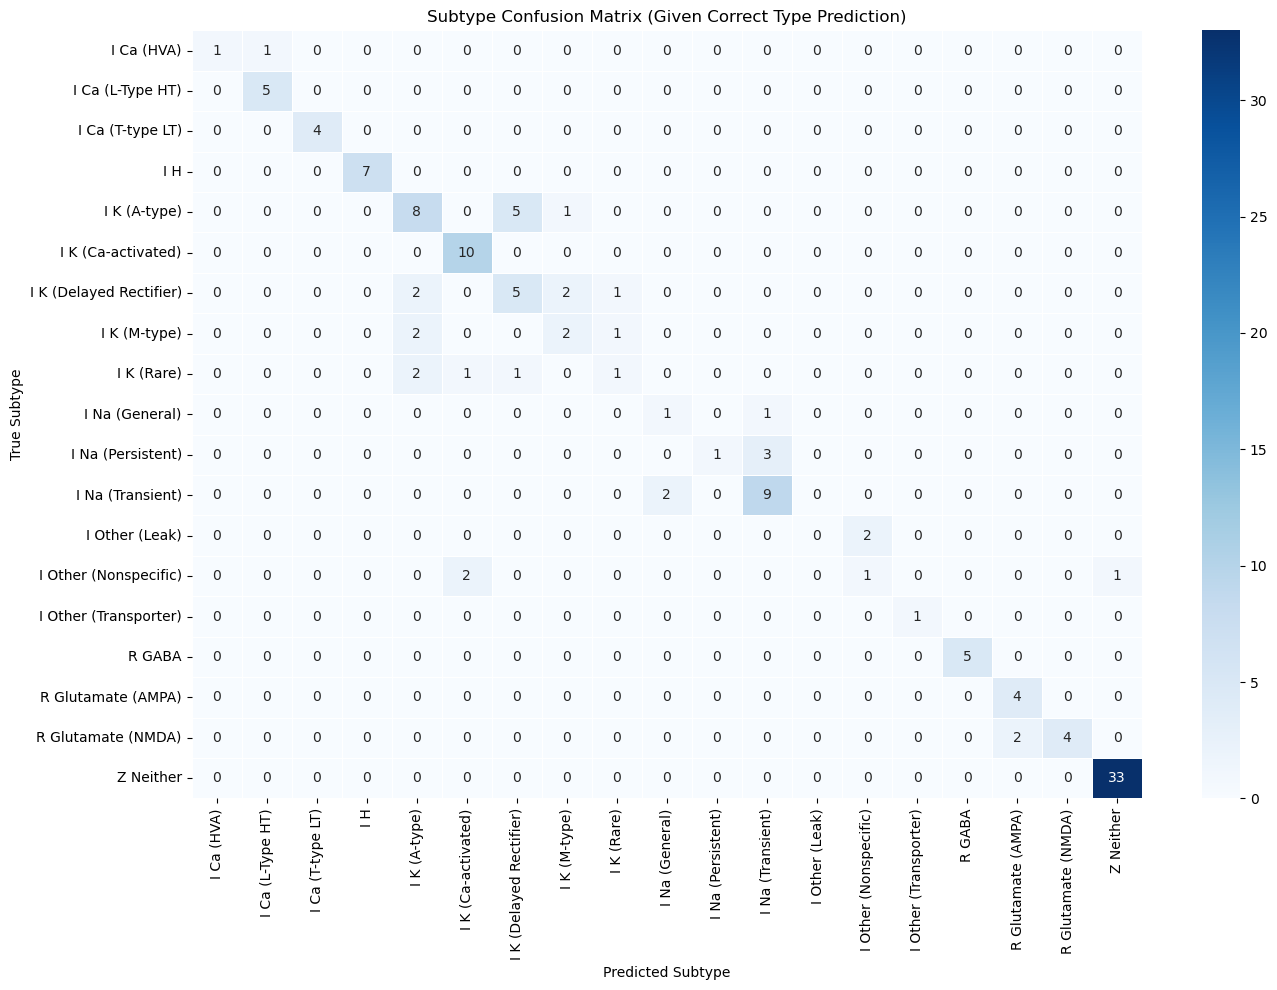


Contingency Table (DataFrame format):


,I Ca (HVA),I Ca (L-Type HT),I Ca (T-type LT),I H,I K (A-type),I K (Ca-activated),I K (Delayed Rectifier),I K (M-type),I K (Rare),I Na (General),I Na (Persistent),I Na (Transient),I Other (Leak),I Other (Nonspecific),I Other (Transporter),R GABA,R Glutamate (AMPA),R Glutamate (NMDA),Z Neither
I Ca (HVA),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
I Ca (L-Type HT),0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
I Ca (T-type LT),0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
I H,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
I K (A-type),0,0,0,0,8,0,5,1,0,0,0,0,0,0,0,0,0,0,0
I K (Ca-activated),0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0
I K (Delayed Rectifier),0,0,0,0,2,0,5,2,1,0,0,0,0,0,0,0,0,0,0
I K (M-type),0,0,0,0,2,0,0,2,1,0,0,0,0,0,0,0,0,0,0
I K (Rare),0,0,0,0,2,1,1,0,1,0,0,0,0,0,0,0,0,0,0
I Na (General),0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create a confusion matrix for subtype predictions (only when type is correct)
conf_matrix = confusion_matrix(filtered_true, filtered_pred, labels=subtype_encoder.classes_)

# Convert to labeled DataFrame for visualization
conf_df = pd.DataFrame(
    conf_matrix,
    index=subtype_encoder.classes_,
    columns=subtype_encoder.classes_
)

# Optional: Display as heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Subtype Confusion Matrix (Given Correct Type Prediction)")
plt.xlabel("Predicted Subtype")
plt.ylabel("True Subtype")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Print raw table
print("\nContingency Table (DataFrame format):")
display(conf_df)


In [34]:
metrics_xgb = get_metrics_df(conf_matrix, labels=subtype_encoder.classes_)
metrics_xgb

,True Positives,Count,TP %
I Ca (HVA),1,2,50.00
I Ca (L-Type HT),5,5,100.00
I Ca (T-type LT),4,4,100.00
I H,7,7,100.00
I K (A-type),8,14,57.14
I K (Ca-activated),10,10,100.00
I K (Delayed Rectifier),5,10,50.00
I K (M-type),2,5,40.00
I K (Rare),1,5,20.00
I Na (General),1,2,50.00


In [35]:
print("\nType Classification Report:")
print(classification_report(
    y_type_test,
    y_type_pred,
    target_names=type_encoder.classes_
))



Type Classification Report:
              precision    recall  f1-score   support

        I Ca       0.92      0.79      0.85        14
         I H       0.78      0.88      0.82         8
         I K       0.94      0.96      0.95        46
        I Na       1.00      1.00      1.00        17
     I Other       1.00      0.78      0.88         9
      R GABA       1.00      0.83      0.91         6
 R Glutamate       0.71      0.91      0.80        11
   Z Neither       0.89      0.89      0.89        37

    accuracy                           0.91       148
   macro avg       0.90      0.88      0.89       148
weighted avg       0.91      0.91      0.91       148




Contingency Table for Type Predictions:
             I Ca  I H  I K  I Na  I Other  R GABA  R Glutamate  Z Neither
I Ca           11    1    1     0        0       0            0          1
I H             0    7    1     0        0       0            0          0
I K             1    1   44     0        0       0            0          0
I Na            0    0    0    17        0       0            0          0
I Other         0    0    0     0        7       0            0          2
R GABA          0    0    0     0        0       5            1          0
R Glutamate     0    0    0     0        0       0           10          1
Z Neither       0    0    1     0        0       0            3         33


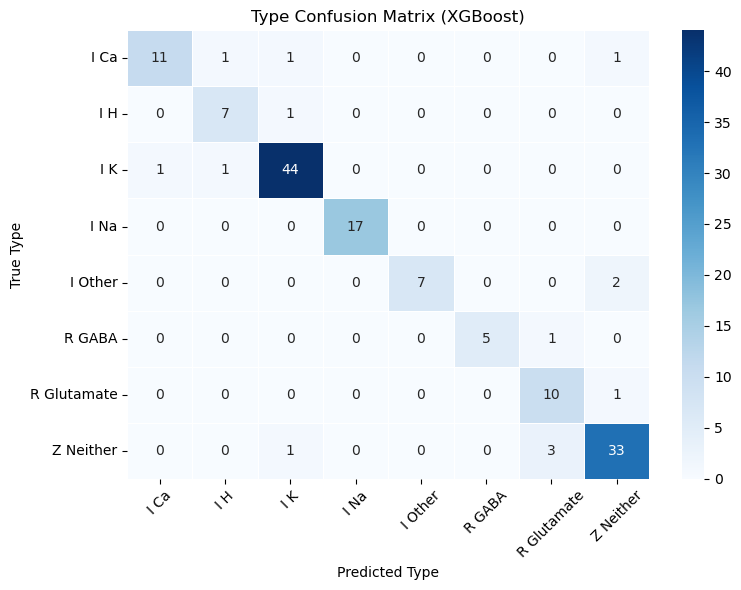

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
type_labels = type_encoder.classes_
type_conf_matrix = confusion_matrix(y_type_test, y_type_pred, labels=type_labels)

# Convert to DataFrame for labeled viewing
type_conf_df = pd.DataFrame(type_conf_matrix, index=type_labels, columns=type_labels)

# Print table
print("\nContingency Table for Type Predictions:")
print(type_conf_df)

# Optional: Plot as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(type_conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
plt.title("Type Confusion Matrix (XGBoost)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [37]:
metrics_xgb_type = get_metrics_df(type_conf_matrix, labels=type_encoder.classes_)


In [38]:
metrics_xgb_type

,True Positives,Count,TP %
I Ca,11,14,78.57
I H,7,8,87.50
I K,44,46,95.65
I Na,17,17,100.00
I Other,7,9,77.78
R GABA,5,6,83.33
R Glutamate,10,11,90.91
Z Neither,33,37,89.19


# Feature Importance

In [39]:
import pandas as pd

# For type model
type_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': type_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top features for TYPE classification:")
print(type_importance_df.head(20))  # adjust as needed

# For subtype model
subtype_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': subtype_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop features for SUBTYPE classification:")
print(subtype_importance_df.head(20))  # adjust as needed


Top features for TYPE classification:
               feature  importance
17         read_e_k_yn    0.160973
18        read_e_na_yn    0.140633
37        write_i_k_yn    0.109169
16        read_e_ca_yn    0.085949
9            has_ih_yn    0.050406
13        read_ca_o_yn    0.050209
35      write_i_cal_yn    0.035381
2            suffix_yn    0.034165
8            has_mg_yn    0.030526
3     point_process_yn    0.026981
28        read_na_o_yn    0.024712
39    write_i_other_yn    0.022203
27        read_na_i_yn    0.021949
11            volt_max    0.020427
10            volt_min    0.018651
5     i_nonspecific_yn    0.016869
6   not_ion_channel_yn    0.016293
19     read_e_other_yn    0.015603
20       read_i_cal_yn    0.015453
0         states_count    0.013898

Top features for SUBTYPE classification:
             feature  importance
9          has_ih_yn    0.089499
18      read_e_na_yn    0.085332
8          has_mg_yn    0.079216
17       read_e_k_yn    0.074439
23      read_i_na_yn

In [40]:
# Create an explainer
#explainer = shap.Explainer(xgb_model, X_test)
# Compute SHAP values
#shap_values = explainer(X_test)
#plt.title("I H")
#plt.title("I K A-type")
#plt.title("I KDR")
#shap.plots.beeswarm(shap_values[:,:,5])

In [41]:
# Decode predicted and true values
true_type = y_type_test.values
true_subtype = y_subtype_test.values
xgb_pred_type = y_type_pred
xgb_pred_subtype = y_subtype_pred

# Construct DataFrame
df_xgb_pred = pd.DataFrame({
    "hash": X_test.index,
    "true_type": true_type,
    "true_subtype": true_subtype,
    "xgb_pred_type": xgb_pred_type,
    "xgb_pred_subtype": xgb_pred_subtype,
})

# Add match flags
df_xgb_pred["xgb_type_match"] = df_xgb_pred["true_type"] == df_xgb_pred["xgb_pred_type"]
df_xgb_pred["xgb_subtype_match"] = df_xgb_pred["true_subtype"] == df_xgb_pred["xgb_pred_subtype"]

# Optional: subset with correct type predictions
df_correct_type = df_xgb_pred[df_xgb_pred["xgb_type_match"]]


In [42]:
df_both = df_xgb_pred.merge(gpt_df3, how="inner", on="hash")

In [43]:
df_both

,hash,true_type,true_subtype,xgb_pred_type,xgb_pred_subtype,xgb_type_match,xgb_subtype_match,gpt_pred_type,gpt_pred_subtype
0,daa17541ed73fab8b517f6b9db0ca4cfd659f6ae487488...,I K,I K (Ca-activated),I K,I K (Ca-activated),True,True,I K,I K (Ca-activated)
1,3f2596becdb8bcdca75d87229d88bad2adce0340908b67...,I Ca,I Ca (L-Type HT),I Ca,I Ca (L-Type HT),True,True,I Ca,I Ca (L-Type HT)
2,ab16fa9433f326fa6012fc5f6436f2e2508d5352f324a2...,I K,I K (A-type),I K,I K (A-type),True,True,I K,I K (A-type)
3,ab16fa9433f326fa6012fc5f6436f2e2508d5352f324a2...,I K,I K (A-type),I K,I K (A-type),True,True,I K,I K (A-type)
4,2d48e869ba4d7f6bc608e4fa38e541f1bae1fa246eaaaa...,I Na,I Na (Persistent),I Na,I Na (Transient),True,False,I Na,I Na (Persistent)
...,...,...,...,...,...,...,...,...,...
101,74e51cd70f64f89036780352514a17f2c41069a63399d3...,I K,I K (Delayed Rectifier),I K,I K (A-type),True,False,I K,I K (Rare)
102,ef74f1b18703155c65934463d95c784c271ddfe39f5d96...,I Ca,I Ca (T-type LT),I Ca,I Ca (T-type LT),True,True,I Ca,I Ca (T-type LT)
103,aeaa32102ec4a98a08d51c98d6323d900b285b408cd83d...,R GABA,R GABA,R GABA,R GABA,True,True,Receptor,R GABA
104,c0516bbe64d9eded07abbdf9e5715fa8d7367d24a0bbcf...,Z Neither,Z Neither,R Glutamate,R Glutamate (NMDA),False,False,Receptor,R Glutamate (NMDA)


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(df_both["true_type"], df_both["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

# === Subtype Accuracy (Only When Type Matches) ===
df_gpt_type_matched = df_both[df_both["true_type"] == df_both["gpt_pred_type"]]
gpt_subtype_acc = accuracy_score(
    df_gpt_type_matched["true_subtype"], df_gpt_type_matched["gpt_pred_subtype"]
)
print(f"GPT Subtype Accuracy (Given Correct Type): {gpt_subtype_acc:.4f}")

# === Classification Report for Subtype (Given Correct Type) ===
print("\nGPT Subtype Classification Report (Given Correct Type):")
print(classification_report(
    df_gpt_type_matched["true_subtype"],
    df_gpt_type_matched["gpt_pred_subtype"]
))


GPT Type Accuracy: 0.7264
GPT Subtype Accuracy (Given Correct Type): 0.8831

GPT Subtype Classification Report (Given Correct Type):
                         precision    recall  f1-score   support

             I Ca (HVA)       1.00      1.00      1.00         2
       I Ca (L-Type HT)       1.00      1.00      1.00         7
       I Ca (T-type LT)       1.00      1.00      1.00         4
                    I H       1.00      1.00      1.00         7
           I K (A-type)       1.00      1.00      1.00        24
     I K (Ca-activated)       1.00      1.00      1.00         4
I K (Delayed Rectifier)       0.00      0.00      0.00         8
           I K (M-type)       1.00      1.00      1.00         4
             I K (Rare)       0.27      1.00      0.43         3
         I Na (General)       0.00      0.00      0.00         1
      I Na (Persistent)       1.00      1.00      1.00         3
       I Na (Transient)       0.88      1.00      0.93         7
  I Other (Nonspecifi

/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


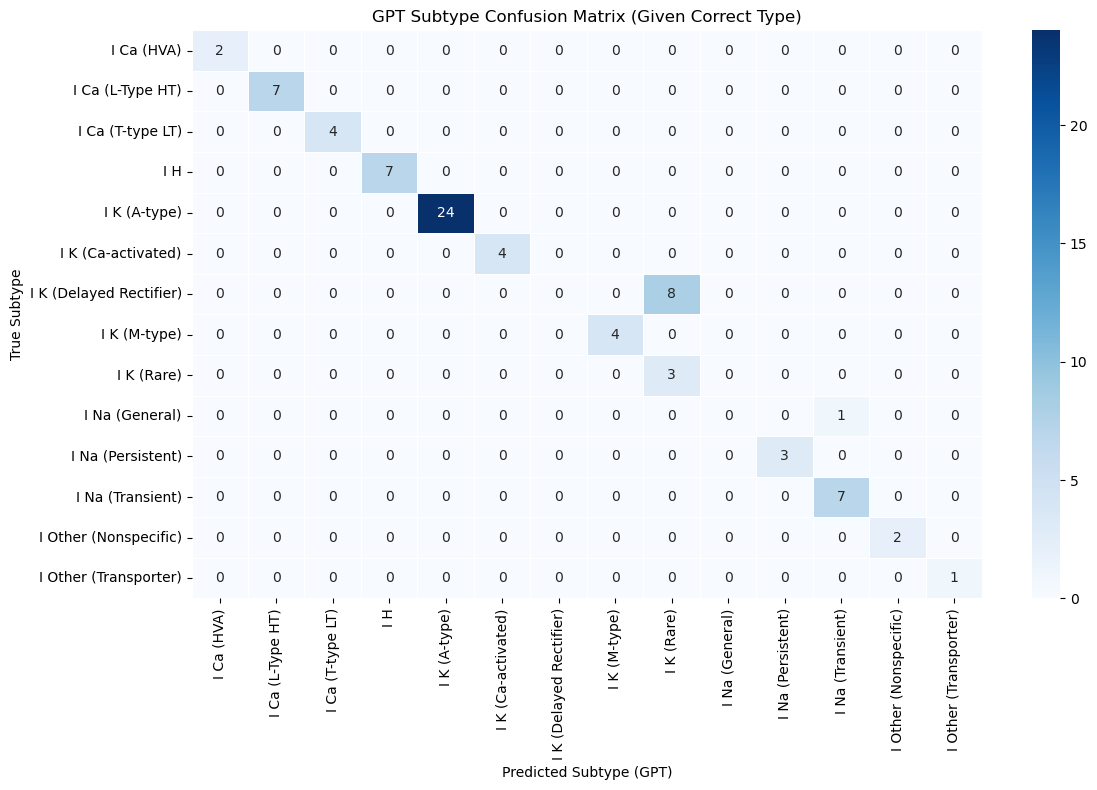

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = np.unique(np.concatenate([
    df_gpt_type_matched["true_subtype"],
    df_gpt_type_matched["gpt_pred_subtype"]
]))

conf_matrix = confusion_matrix(
    df_gpt_type_matched["true_subtype"],
    df_gpt_type_matched["gpt_pred_subtype"],
    labels=labels
)

conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Subtype (GPT)")
plt.ylabel("True Subtype")
plt.title("GPT Subtype Confusion Matrix (Given Correct Type)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [46]:
# Get metrics DataFrame
metrics_gpt = get_metrics_df(conf_matrix, labels=labels)
metrics_gpt

,True Positives,Count,TP %
I Ca (HVA),2,2,100.0
I Ca (L-Type HT),7,7,100.0
I Ca (T-type LT),4,4,100.0
I H,7,7,100.0
I K (A-type),24,24,100.0
I K (Ca-activated),4,4,100.0
I K (Delayed Rectifier),0,8,0.0
I K (M-type),4,4,100.0
I K (Rare),3,3,100.0
I Na (General),0,1,0.0


In [47]:
#Define subtype → family mapping
subtype_to_family = {
    'I Ca (HVA)': 'I Ca Family',
    'I Ca (L-Type HT)': 'I Ca Family',
    'I Ca (T-type LT)': 'I Ca Family',
    'I H': 'I H Family',
    'I K (A-type)': 'I K Family',
    'I K (Ca-activated)': 'I K Family',
    'I K (Delayed Rectifier)': 'I K Family',
    'I K (M-type)': 'I K Family',
    'I K (Rare)': 'I K Family',
    'I Na (Transient)': 'I Na Family',
    'I Na (Persistent)': 'I Na Family',
    'I Na (General)': 'I Na Family',
    'I Other (Leak)': 'Other/Neither Family',
    'I Other (Nonspecific)': 'Other/Neither Family',
    'I Other (Transporter)': 'Other/Neither Family',
    'Z Neither': 'Z Neither',
    'R GABA': 'Receptors Family',
    'R Glutamate (AMPA)': 'Receptors Family',
    'R Glutamate (NMDA)': 'Receptors Family'
}


In [48]:
# Ensure you have both original metrics
# metrics_xgb and metrics_gpt

combined_metrics = metrics_xgb.rename(
    columns={
        "TP %": "TP % (XGB)",
        "True Positives": "TP (XGB)",
        "Count": "n_xgb"
    }
).join(
    metrics_gpt.rename(
        columns={
            "TP %": "TP % (GPT)",
            "True Positives": "TP (GPT)",
            "Count": "n_gpt"
        }
    ),
    how="outer"
)

# Add ion family
combined_metrics["Family"] = combined_metrics.index.map(subtype_to_family)


combined_metrics = combined_metrics.sort_index()

In [49]:
combined_metrics.reset_index().to_csv("../data/combined_metrics.csv")

In [50]:
combined_metrics

,TP (XGB),n_xgb,TP % (XGB),TP (GPT),n_gpt,TP % (GPT),Family
I Ca (HVA),1,2,50.00,2.0,2.0,100.0,I Ca Family
I Ca (L-Type HT),5,5,100.00,7.0,7.0,100.0,I Ca Family
I Ca (T-type LT),4,4,100.00,4.0,4.0,100.0,I Ca Family
I H,7,7,100.00,7.0,7.0,100.0,I H Family
I K (A-type),8,14,57.14,24.0,24.0,100.0,I K Family
I K (Ca-activated),10,10,100.00,4.0,4.0,100.0,I K Family
I K (Delayed Rectifier),5,10,50.00,0.0,8.0,0.0,I K Family
I K (M-type),2,5,40.00,4.0,4.0,100.0,I K Family
I K (Rare),1,5,20.00,3.0,3.0,100.0,I K Family
I Na (General),1,2,50.00,0.0,1.0,0.0,I Na Family


In [51]:
# Extract data
subtypes = combined_metrics.index.tolist()
xgb_tp_pct = combined_metrics["TP % (XGB)"].values
gpt_tp_pct = combined_metrics["TP % (GPT)"].values
xgb_tp = combined_metrics["TP (XGB)"].values
gpt_tp = combined_metrics["TP (GPT)"].values
xgb_n = combined_metrics["n_xgb"].values
gpt_n = combined_metrics["n_gpt"].values

# Setup plot
x = np.arange(len(subtypes))  # label locations
width = 0.35  # width of bars


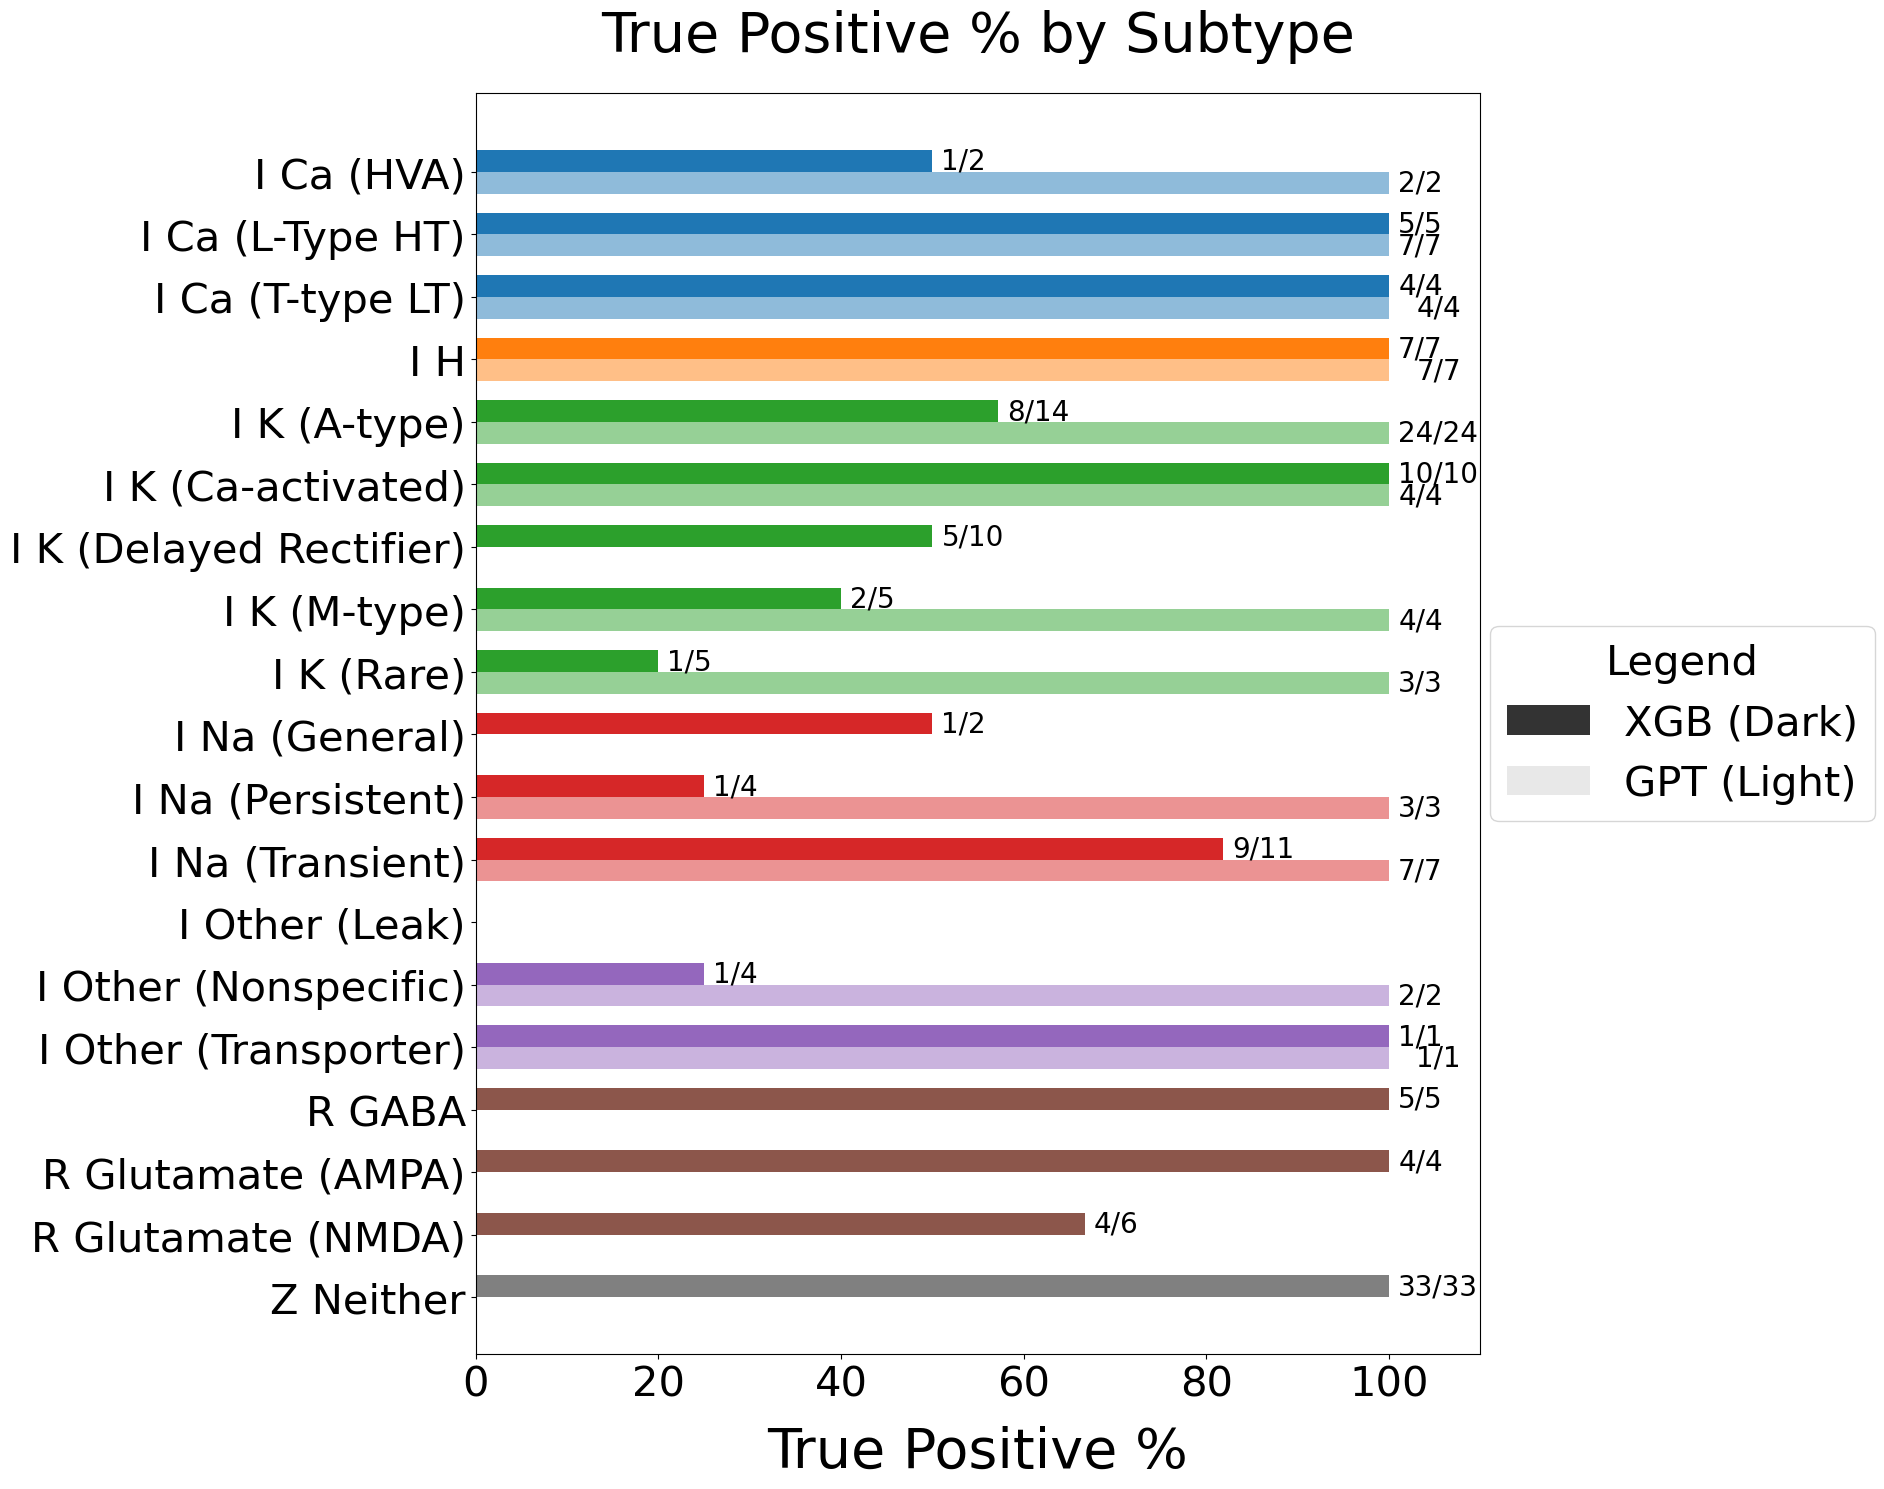

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ===== Set global font size =====
SIZE = 30
TITLE_SIZE = 40

# Copy and reset index
combined_metrics = combined_metrics.copy()
combined_metrics["Subtype"] = combined_metrics.index

# Normalize Family names
combined_metrics["Family"] = combined_metrics["Family"].astype(str).str.strip()

# Sort alphabetically by subtype
combined_metrics.sort_values("Subtype", inplace=True)

# Extract data
subtypes = combined_metrics["Subtype"].tolist()
families = combined_metrics["Family"].tolist()
y = np.arange(len(subtypes))
height = 0.35

xgb_tp_pct = combined_metrics["TP % (XGB)"].values
gpt_tp_pct = combined_metrics["TP % (GPT)"].values
xgb_tp = combined_metrics["TP (XGB)"].values
gpt_tp = combined_metrics["TP (GPT)"].values
xgb_n = combined_metrics["n_xgb"].values
gpt_n = combined_metrics["n_gpt"].values

# Unique families
unique_families = sorted(set(families))

# Define family -> color map
base_colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
family_color_map = {}
color_index = 0
for fam in unique_families:
    if fam.lower() == "z neither":
        family_color_map[fam] = "gray"
    else:
        family_color_map[fam] = base_colors[color_index % len(base_colors)]
        color_index += 1

# Brightness adjustments
def lighten(color, factor=0.5):
    rgb = mcolors.to_rgb(color)
    return tuple(1 - (1 - c) * factor for c in rgb)

def darken(color, factor=0.8):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

# Bar colors (XGB = dark, GPT = light)
xgb_colors = [darken(family_color_map[fam], 1.0) for fam in families]
gpt_colors = [lighten(family_color_map[fam], 0.5) for fam in families]

# Plot
fig, ax = plt.subplots(figsize=(20, 15))
bars1 = ax.barh(y - height/2, xgb_tp_pct, height, label='XGB', color=xgb_colors)
bars2 = ax.barh(y + height/2, gpt_tp_pct, height, label='GPT', color=gpt_colors)

# TP / Count labels
for bar1, bar2, tp1, count1, tp2, count2 in zip(bars1, bars2, xgb_tp, xgb_n, gpt_tp, gpt_n):
    if not (pd.isna(tp1) or pd.isna(count1)) and tp1 > 0:
        ax.text(bar1.get_width() + 1, bar1.get_y() + bar1.get_height()/2,
                f'{int(tp1)}/{int(count1)}', va='center', fontsize=int(SIZE * 0.67))
    if not (pd.isna(tp2) or pd.isna(count2)) and tp2 > 0:
        offset = 3 if (tp1 == tp2 and count1 == count2) else 1
        ax.text(bar2.get_width() + offset, bar2.get_y() + bar2.get_height()/2,
                f'{int(tp2)}/{int(count2)}', va='center', fontsize=int(SIZE * 0.67))

# Axes
ax.set_xlabel('True Positive %', fontsize=TITLE_SIZE, labelpad=SIZE // 2)
ax.set_title('True Positive % by Subtype', fontsize=TITLE_SIZE, pad=SIZE)
ax.set_yticks(y)
ax.set_yticklabels(subtypes, fontsize=SIZE)
ax.set_xlim(0, 110)
ax.tick_params(axis='x', labelsize=SIZE)
ax.grid(False)
ax.invert_yaxis()

# ✅ Ultra-simplified legend
model_patches = [
    Patch(facecolor='black', label='XGB (Dark)', alpha=0.8),
    Patch(facecolor='lightgray', label='GPT (Light)', alpha=0.5)
]
ax.legend(
    handles=model_patches,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    borderaxespad=0.,
    fontsize=SIZE,
    title="Legend",
    title_fontsize=SIZE
)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


# Captstone Results

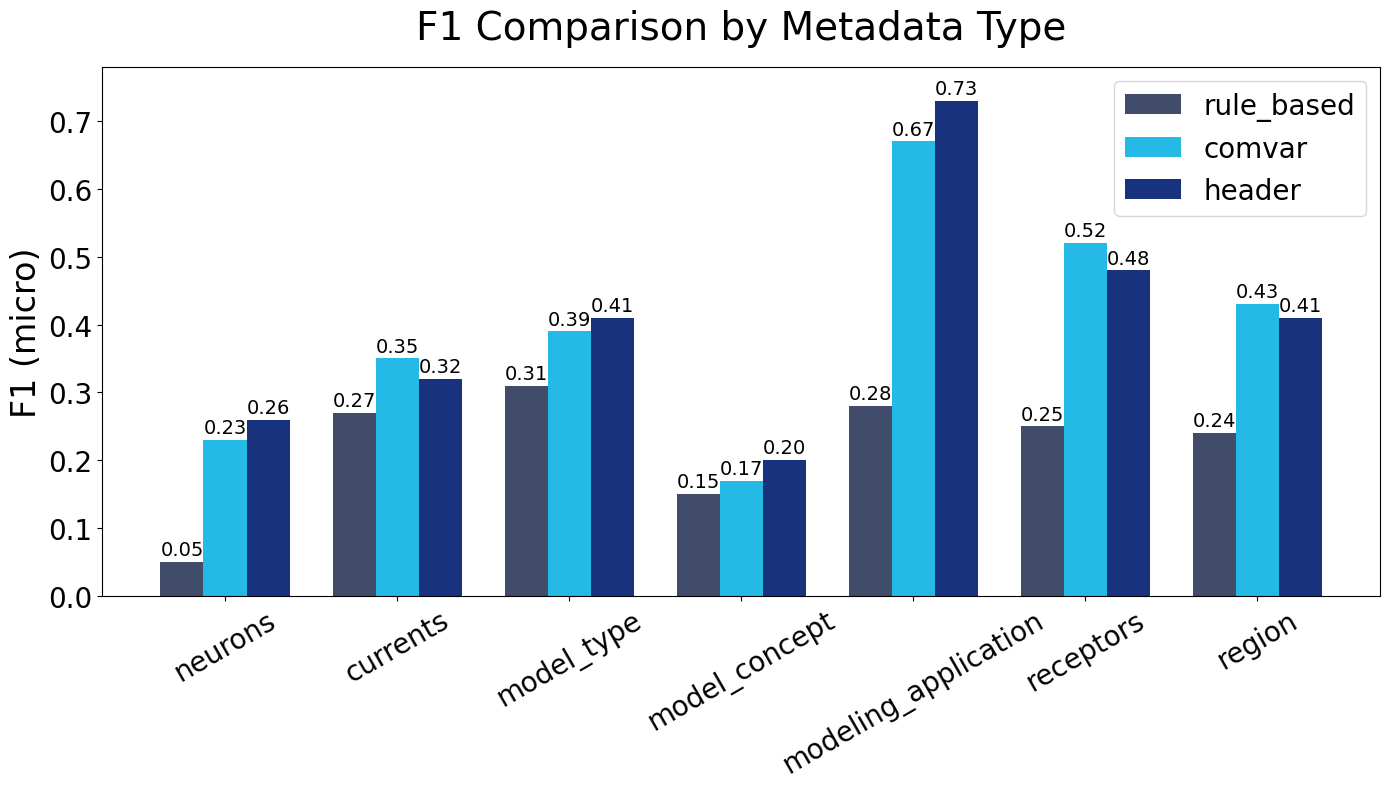

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Metadata categories
metadata_types = [
    "neurons", "currents", "model_type", "model_concept",
    "modeling_application", "receptors", "region"
]

# F1 scores
rule_based = [0.05, 0.27, 0.31, 0.15, 0.28, 0.25, 0.24]
comvar = [0.23, 0.35, 0.39, 0.17, 0.67, 0.52, 0.43]
header = [0.26, 0.32, 0.41, 0.20, 0.73, 0.48, 0.41]

# Bar setup
x = np.arange(len(metadata_types))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width, rule_based, width, label='rule_based', color='#414C6B')
bars2 = ax.bar(x, comvar, width, label='comvar', color='#25b9e5')
bars3 = ax.bar(x + width, header, width, label='header', color='#18327e')

# Labels and titles with larger fonts
ax.set_ylabel("F1 (micro)", fontsize=24)
ax.set_title("F1 Comparison by Metadata Type", fontsize=28, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metadata_types, rotation=30, fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=20)

# Place value labels directly above bars with minimal spacing
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 2),  # minimal vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=14)

# Tighter Y-axis limit
ax.set_ylim(0, max(header) + 0.05)

plt.tight_layout()
plt.show()

In [2]:
!git add .
!git commit -m "re-organized folders"
!git push

[main a75208c] re-organized folders
 29 files changed, 32 insertions(+), 4751 deletions(-)
 delete mode 100644 code/INaP_response_plot.png
 delete mode 100644 code/NaP.mod
 delete mode 100644 code/Untitled.ipynb
 delete mode 100644 code/cal2.mod
 delete mode 100644 code/cal_response_plot.png
 delete mode 100644 code/ka.mod
 delete mode 100644 code/ka_response_plot.png
 delete mode 100644 code/kap_response_plot.png
 delete mode 100644 code/kaprox.mod
 delete mode 100644 code/kv72wt73wt.mod
 delete mode 100644 code/kv72wt73wt_response_plot.png
 delete mode 100644 code/mod_files_sample.json
 delete mode 100755 code/x86_64/.libs/libnrnmech.so
 delete mode 100644 code/x86_64/NaP.c
 delete mode 100644 code/x86_64/NaP.o
 delete mode 100644 code/x86_64/cal2.c
 delete mode 100644 code/x86_64/cal2.o
 delete mode 100644 code/x86_64/ka.c
 delete mode 100644 code/x86_64/ka.o
 delete mode 100644 code/x86_64/kaprox.c
 delete mode 100644 code/x86_64/kaprox.o
 delete mode 100644 code/x86_64/kv72wt73wt.